# Employee Attrition Prediction using Machine Learning

## Task 1: Data Loading and Exploration

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation Metrics

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv("C:/Users/Akanksha/Downloads/EmployeeAttrition_Akanksha/WA_Fn-UseC_-HR-Employee-Attrition.csv")
# Display first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
# Check number of rows and columns
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1470, 35)


In [7]:
# Check target column
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
# Count employees who left and stayed
attrition_count = df["Attrition"].value_counts()
print(attrition_count)

# Calculate attrition percentage
attrition_rate = (
    attrition_count["Yes"] /
    len(df)
) * 100
print("Attrition Rate:", round(attrition_rate,2), "%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate: 16.12 %


In [11]:
# Count numeric columns
numeric_cols = df.select_dtypes(
    include=np.number
).columns

# Count categorical columns
categorical_cols = df.select_dtypes(
    exclude=np.number
).columns
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


### Observation
The dataset is imbalanced because a significantly larger number of employees stayed with the company (1233) compared to those who left (237). The attrition rate is 16.12%, indicating that employee attrition occurs in a relatively small portion of the workforce. This class imbalance should be considered during model training and evaluation to ensure accurate predictions.

# Task 2: Data Cleaning and Preprocessing

In [13]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation
No missing values were found in the dataset. Therefore, no missing value treatment was required before preprocessing.

In [15]:
# Check duplicate records
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Observation
No duplicate records were found in the dataset.

In [17]:
# Check unique values in constant columns
print(df["EmployeeCount"].unique())
print(df["Over18"].unique())
print(df["StandardHours"].unique())

[1]
['Y']
[80]


In [19]:
# Remove irrelevant and constant columns
df = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)
print(df.shape)

(1470, 31)


In [21]:
# Convert Attrition into binary format
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})
df["Attrition"].head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

In [23]:
# Identify categorical columns
categorical_cols = df.select_dtypes(
    include="object"
).columns
print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [25]:
# Convert categorical variables into numerical form
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [37]:
print(X.shape)

(1470, 44)


In [27]:
# Create X and y
X = df.drop("Attrition", axis=1)
y = df["Attrition"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 44)
Target Shape: (1470,)


In [31]:
# Split dataset into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 44)
Testing Data: (294, 44)


In [33]:
print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


In [35]:
# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


### Preprocessing Summary
The dataset was checked for missing values and duplicate records. Irrelevant and constant columns were removed to improve model performance. The target variable Attrition was converted into binary format, categorical features were encoded using One-Hot Encoding, and numerical features were standardized using StandardScaler. Finally, the dataset was split into training and testing sets for machine learning model development.

# Task 3: Exploratory Data Analysis (EDA)

In [39]:
# Reload original dataset for EDA
eda_df = pd.read_csv("C:/Users/Akanksha/Downloads/EmployeeAttrition_Akanksha/WA_Fn-UseC_-HR-Employee-Attrition.csv")
eda_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


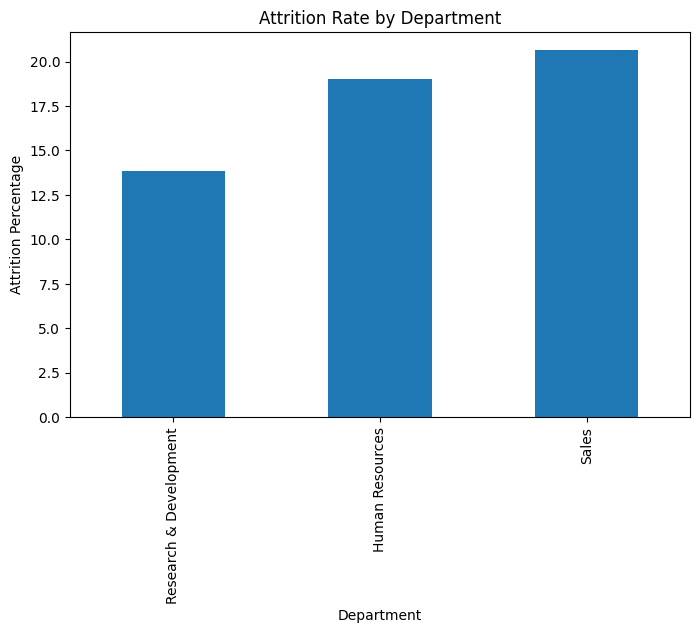

In [41]:
# Attrition rate by department
department_attrition = pd.crosstab(
    eda_df["Department"],
    eda_df["Attrition"],
    normalize="index"
) * 100
print(department_attrition)
department_attrition["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Percentage")
plt.xlabel("Department")
plt.show()

Attrition                         No        Yes
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


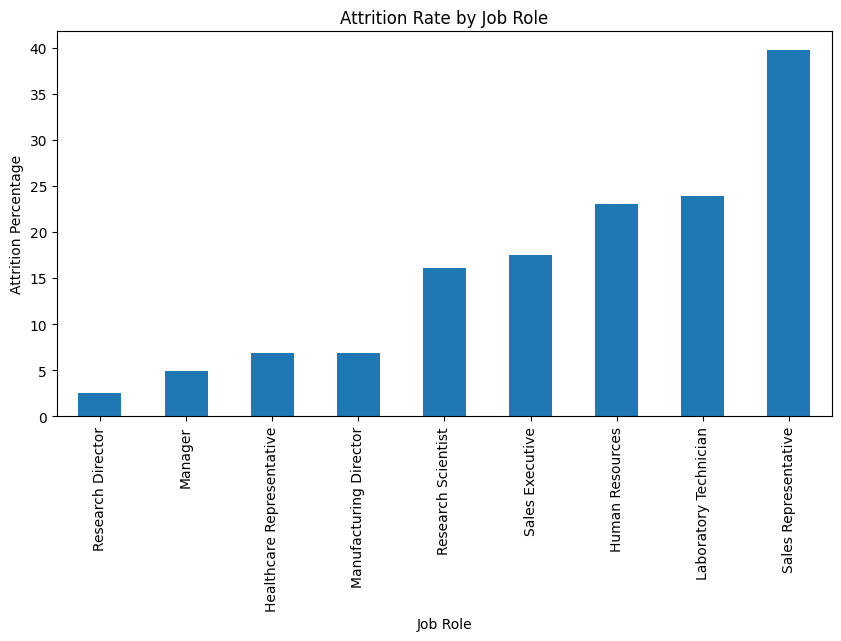

In [43]:
# Attrition rate by job role
jobrole_attrition = pd.crosstab(
    eda_df["JobRole"],
    eda_df["Attrition"],
    normalize="index"
) * 100
print(jobrole_attrition)
jobrole_attrition["Yes"].sort_values().plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Percentage")
plt.xlabel("Job Role")
plt.show()

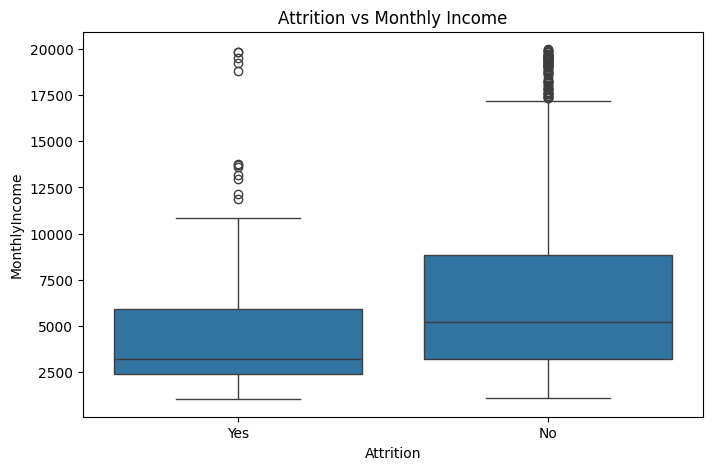

In [45]:
# Monthly income comparison
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df
)
plt.title("Attrition vs Monthly Income")
plt.show()

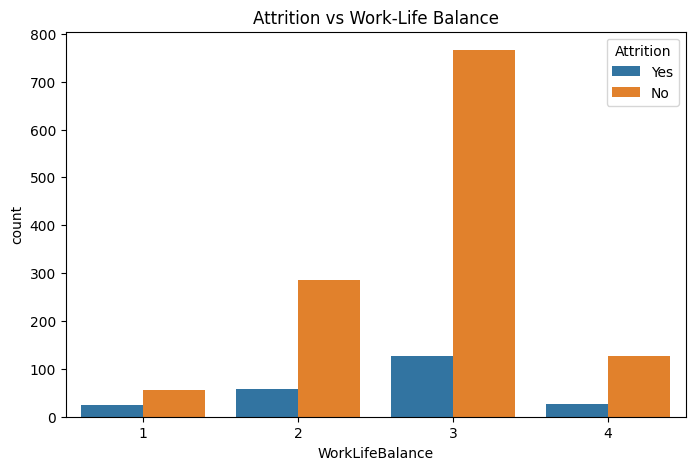

In [47]:
# Work-life balance analysis
plt.figure(figsize=(8,5))
sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=eda_df
)
plt.title("Attrition vs Work-Life Balance")
plt.show()

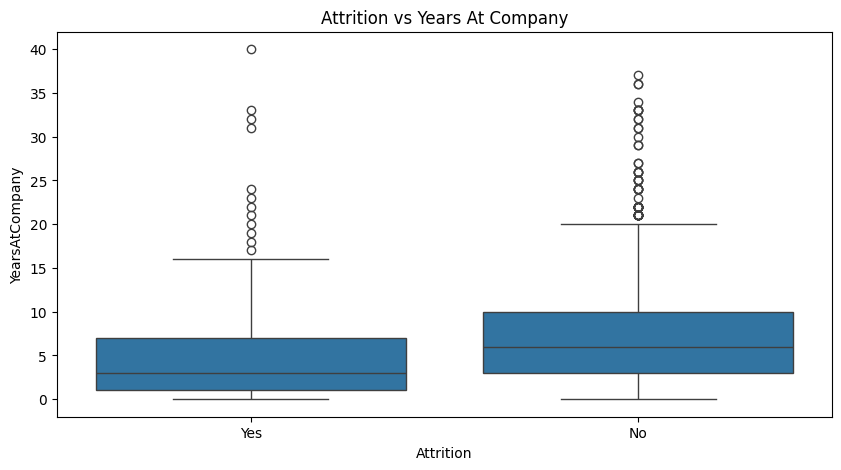

In [49]:
# Years at company
plt.figure(figsize=(10,5))
sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=eda_df
)
plt.title("Attrition vs Years At Company")
plt.show()

In [51]:
plt.savefig("chart_name.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [57]:
plt.savefig("department_attrition.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

### Business Insights

1. The Sales department has the highest attrition rate (approximately 21%), followed by Human Resources (19%), while Research & Development has the lowest attrition rate (14%). This indicates that employee retention efforts should focus more on Sales and HR departments.

2. Sales Representatives experience the highest attrition rate (around 40%), which is significantly higher than all other job roles. This suggests that this role may have higher work pressure, lower job satisfaction, or better external opportunities.

3. Employees who leave the company generally have lower monthly incomes compared to employees who stay. This indicates that compensation may be one of the factors influencing employee turnover.

4. Employees with lower work-life balance ratings appear to leave more frequently than employees with better work-life balance ratings. This suggests that improving work-life balance policies may help reduce attrition.

5. Employees who leave the company tend to have fewer years at the company compared to those who stay. This indicates that attrition is more common among relatively newer employees, making early employee engagement and onboarding important.

In [55]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1176, 44)
(294, 44)
(1176,)
(294,)


# Task 4: Model Building and Comparison

In [59]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
# Create Logistic Regression Model
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)
# Train Model
lr_model.fit(X_train, y_train)
# Predictions
lr_pred = lr_model.predict(X_test)
print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [61]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier
# Create Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
# Train Model
rf_model.fit(X_train, y_train)
# Predictions
rf_pred = rf_model.predict(X_test)
print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [63]:
# Import Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# Create Gradient Boosting Model
gb_model = GradientBoostingClassifier(
    random_state=42
)
# Train Model
gb_model.fit(X_train, y_train)
# Predictions
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [65]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
# Create comparison table
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748
1,Random Forest,0.836735,0.444444,0.085106,0.142857
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500


### Model Comparison Observation

Three machine learning models were trained and compared for employee attrition prediction. Gradient Boosting achieved the highest accuracy (85.03%) and precision (58.82%), while Logistic Regression achieved the highest recall (61.70%) and F1-score (44.27%). Since employee attrition prediction is a business problem where identifying employees who may leave is important, Logistic Regression performed well in capturing attrition cases. However, Gradient Boosting provided the highest overall accuracy among the three models.

# Task 5: Model Evaluation

In [67]:
# Classification Reports
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred))

print("\nRANDOM FOREST")
print(classification_report(y_test, rf_pred))

print("\nGRADIENT BOOSTING")
print(classification_report(y_test, gb_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294


GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0

In [69]:
# ROC AUC Scores
from sklearn.metrics import roc_auc_score
lr_auc = roc_auc_score(
    y_test,
    lr_model.predict_proba(X_test)[:,1]
)
rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)
gb_auc = roc_auc_score(
    y_test,
    gb_model.predict_proba(X_test)[:,1]
)
print("Logistic Regression ROC-AUC:", lr_auc)
print("Random Forest ROC-AUC:", rf_auc)
print("Gradient Boosting ROC-AUC:", gb_auc)

Logistic Regression ROC-AUC: 0.7982599707123783
Random Forest ROC-AUC: 0.7547161684899647
Gradient Boosting ROC-AUC: 0.7941252476526832


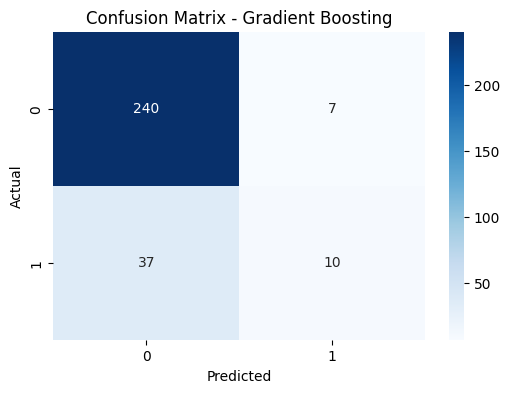

In [71]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, gb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Best Model Selection

Although Gradient Boosting achieved the highest accuracy (85.03%), Logistic Regression was selected as the best model for employee attrition prediction because it achieved the highest recall (61.70%) and F1-score (44.27%) for the attrition class. In employee attrition prediction, identifying employees who are likely to leave is more important than overall accuracy. Therefore, Logistic Regression provides better business value by successfully identifying a larger proportion of employees at risk of leaving the company.

In [73]:
# Extract Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})
# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.109081
0,Age,0.093560
43,OverTime_Yes,0.088694
16,TotalWorkingYears,0.084067
11,NumCompaniesWorked,0.050086
15,StockOptionLevel,0.047100
1,DailyRate,0.045122
22,YearsWithCurrManager,0.043015
4,EnvironmentSatisfaction,0.038851
6,JobInvolvement,0.038142


### Feature Importance Analysis

The feature importance analysis revealed that Monthly Income is the most influential factor in predicting employee attrition, followed by Age, Overtime, and Total Working Years. Employees with lower income levels, overtime responsibilities, and lower overall experience appear to have a higher likelihood of leaving the organization. Work environment factors such as Environment Satisfaction and Job Involvement also contribute to attrition, highlighting the importance of employee engagement and workplace satisfaction.

### Task 5 Conclusion

Three machine learning models were evaluated using Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix. Although Gradient Boosting achieved the highest accuracy, Logistic Regression demonstrated the best ability to identify employees at risk of leaving the organization through its superior recall score. Feature importance analysis showed that compensation, age, overtime, work experience, and employee engagement factors play a significant role in employee attrition.

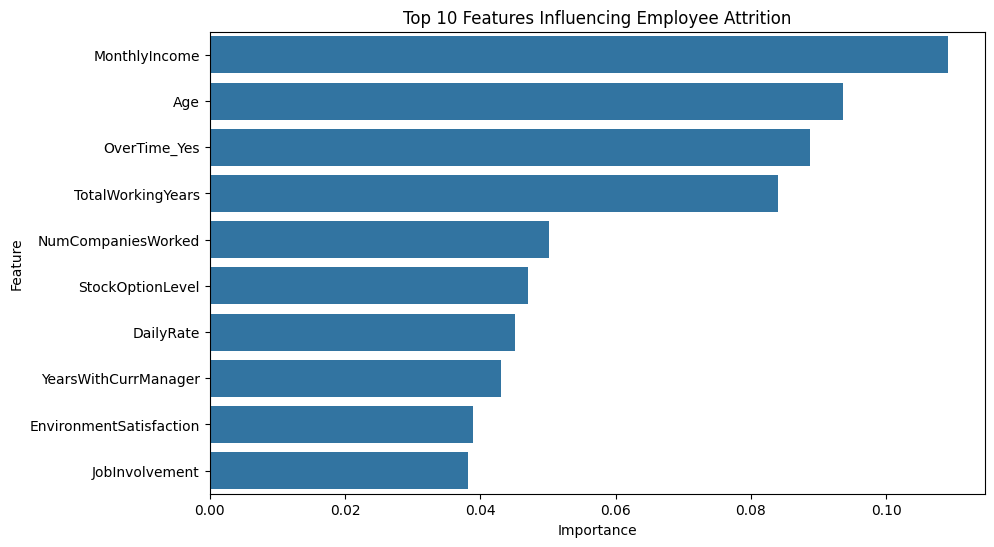

In [77]:
# Top 10 Feature Importance Chart
top10 = feature_importance.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)
plt.title("Top 10 Features Influencing Employee Attrition")
plt.savefig(
    "feature_importance.png",
    bbox_inches='tight'
)
plt.show()

# Task 6: Visualization

### Chart 1: Attrition Rate by Department and Job Role
This chart shows that the Sales department and Sales Representative role experience the highest employee attrition rates.

### Chart 2: Monthly Income vs Attrition
This box plot compares monthly income distributions for employees who left and those who stayed. Employees who left generally have lower income levels.

### Chart 3: Confusion Matrix
The confusion matrix shows how effectively the selected model identifies employees who are likely to leave and those who are likely to stay.

### Chart 4: Top 10 Feature Importance
This chart highlights the most influential factors affecting employee attrition. Monthly Income, Age, Overtime, and Total Working Years are among the strongest predictors.

### Chart 5 (Bonus): ROC Curve Comparison
The ROC Curve compares the predictive performance of Logistic Regression, Random Forest, and Gradient Boosting models.

### Visualization Summary
The visualizations reveal that attrition is highest in the Sales department and among Sales Representatives. Employees with lower income levels and shorter tenure are more likely to leave. Feature importance analysis shows that Monthly Income, Age, Overtime, and Total Working Years are key factors influencing employee attrition.

# Task 7: HR Insights and Business Recommendations

### HR Insights and Business Recommendations

The analysis indicates that Monthly Income, Age, and Overtime are the three strongest factors influencing employee attrition. Employees with lower salaries, younger age groups, and overtime responsibilities are more likely to leave the organization. The Sales department and Sales Representative job role show the highest attrition rates and should be prioritized for retention efforts. Salary alone does not explain attrition, as factors such as overtime, work environment satisfaction, job involvement, and overall work experience also play important roles. To reduce attrition, HR should focus on improving compensation and career growth opportunities for high-risk employees. Additionally, reducing excessive overtime and improving employee engagement programs may help increase retention. One limitation of this model is that it is based on historical data and cannot capture personal or external factors that may influence an employee's decision to leave.

# Project Conclusion

In this project, employee attrition prediction was performed using machine learning techniques. The dataset was cleaned, preprocessed, and analyzed to identify patterns associated with employee turnover. Multiple classification models were trained and evaluated, with Logistic Regression providing the most useful results for identifying employees at risk of leaving. The analysis revealed that salary, overtime, age, and work experience are major factors influencing attrition. The insights generated from this project can help HR teams take proactive actions to improve employee retention and reduce turnover costs.